# Exploring Hypothetical Hardware

The [previous notebooks](0_getting_started.ipynb) showed how to use the quantum
resource estimator with built-in models like `GateBased`, `SurfaceCode`, and
`Litinski19Factory`.  These models capture well-studied hardware assumptions,
but what if your hardware doesn't match them?

In this notebook we build **custom models** to answer three "what if" questions:

- **Architecture model:** What if my qubits had different gate speeds and error rates?
- **QEC ISA transform:** What if I had a QEC code with a higher threshold or lower overhead?
- **Factory transform:** What if my magic state distillation protocol were different?

Each model plugs into the estimator's layered architecture.  You implement a
small Python class and the estimator takes care of the rest: enumerating
configurations, pruning infeasible ones, and finding the Pareto-optimal results.

We finish by composing all three custom layers into a full estimation stack and
comparing it against the built-in models.

In [1]:
from dataclasses import KW_ONLY, dataclass, field
from math import ceil
from typing import Generator

import qdk
from qdk.qre import (
    Architecture,
    ISAContext,
    ConstraintBound,
    ISA,
    ISARequirements,
    ISATransform,
    LOGICAL,
    PHYSICAL,
    constraint,
    estimate,
    linear_function,
    plot_estimates,
)
from qdk.qre.models import GateBased, SurfaceCode, Litinski19Factory
from qdk.qre.application import QSharpApplication
from qdk.qre.instruction_ids import (
    H, S, S_DAG, T, T_DAG, CNOT, CZ, MEAS_X, MEAS_Y, MEAS_Z, LATTICE_SURGERY,
)

## Setup and baseline

We start with a simple Q# program and a baseline estimation using the built-in
models.  This gives us a reference point to compare against later.

In [2]:
%%qsharp

import Std.Arithmetic.*;
import Std.Math.*;
import Std.Convert.*;

/// An 8-bit adder with single-qubit rotations.
/// The rotations introduce T gates via synthesis, which exercises
/// the magic state factory during resource estimation.
operation AdderWithRotations() : Unit {
    use a = Qubit[8];
    use b = Qubit[8];
    for i in 0..7 {
        Ry(PI() / IntAsDouble(i + 2), a[i]);
    }
    RippleCarryCGIncByLE(a, b);
}

In [3]:
app = QSharpApplication(qdk.code.AdderWithRotations)

# Baseline: built-in architecture, QEC, and factory
baseline_arch = GateBased(error_rate=1e-4, gate_time=100, measurement_time=500)
baseline = estimate(
    app, baseline_arch,
    isa_query=SurfaceCode.q() * Litinski19Factory.q(),
    max_error=0.01,
    name="Built-in models",
)
baseline.add_qubit_partition_column()
baseline.add_factory_summary_column()
baseline.as_frame()

,name,qubits,runtime,error,physical_compute_qubits,physical_factory_qubits,physical_memory_qubits,factories
0,Built-in models,9567,0 days 00:00:00.000225,0.007312,3087,6480,0,8×T
1,Built-in models,13221,0 days 00:00:00.000141,0.009416,1071,12150,0,15×T


## Building a custom architecture model

An `Architecture` defines the physical instruction set of a quantum computer:
the native operations the hardware can perform, each with a gate time and error
rate.

The built-in `GateBased` architecture uses a single error rate for all gates.
In practice, two-qubit gates are typically noisier and slower than single-qubit
gates, and measurement fidelities may differ from gate fidelities.  Let's build
a more flexible architecture that models these differences.

To implement a custom architecture, subclass `Architecture` and implement one
method: `provided_isa`.  This method receives an `ISAContext` and uses it to
register each physical instruction.

In [4]:
@dataclass
class ParameterizedArchitecture(Architecture):
    """
    A configurable architecture with separate timing and error parameters for
    single-qubit gates, two-qubit gates, and measurements.

    Unlike the built-in ``GateBased`` model (which uses one error rate for all
    operations), this model lets you specify different error rates for each gate
    class, reflecting hardware where two-qubit gates are noisier than
    single-qubit gates.
    """

    _: KW_ONLY
    single_qubit_gate_time: int
    two_qubit_gate_time: int
    measurement_time: int
    single_qubit_error_rate: float
    two_qubit_error_rate: float
    measurement_error_rate: float

    def provided_isa(self, ctx: ISAContext) -> ISA:
        instructions = []

        # Single-qubit gates: Clifford gates and T gates
        for gate_id in [H, S, S_DAG, T, T_DAG]:
            instructions.append(
                ctx.add_instruction(
                    gate_id,
                    encoding=PHYSICAL,
                    arity=1,
                    time=self.single_qubit_gate_time,
                    error_rate=self.single_qubit_error_rate,
                )
            )

        # Measurements
        for meas_id in [MEAS_X, MEAS_Y, MEAS_Z]:
            instructions.append(
                ctx.add_instruction(
                    meas_id,
                    encoding=PHYSICAL,
                    arity=1,
                    time=self.measurement_time,
                    error_rate=self.measurement_error_rate,
                )
            )

        # Two-qubit entangling gates
        for gate_id in [CNOT, CZ]:
            instructions.append(
                ctx.add_instruction(
                    gate_id,
                    encoding=PHYSICAL,
                    arity=2,
                    time=self.two_qubit_gate_time,
                    error_rate=self.two_qubit_error_rate,
                )
            )

        return ctx.make_isa(*instructions)

### What if my qubits had different characteristics?

Let's explore two hypothetical hardware scenarios:

- **Fast but noisy:** short gate times, higher error rates (reminiscent of
  some superconducting platforms)
- **Slow but clean:** longer gate times, lower error rates (reminiscent of
  some trapped-ion platforms)

We use the built-in `SurfaceCode` and `Litinski19Factory` transforms so that we
isolate the effect of the architecture.

In [5]:
fast_noisy = ParameterizedArchitecture(
    single_qubit_gate_time=50,
    two_qubit_gate_time=100,
    measurement_time=200,
    single_qubit_error_rate=1e-4,
    two_qubit_error_rate=5e-4,
    measurement_error_rate=5e-4,
)

slow_clean = ParameterizedArchitecture(
    single_qubit_gate_time=500,
    two_qubit_gate_time=1000,
    measurement_time=1000,
    single_qubit_error_rate=1e-6,
    two_qubit_error_rate=5e-6,
    measurement_error_rate=1e-5,
)

# Inspect the physical ISA provided by the fast-but-noisy architecture
fast_noisy.provided_isa(fast_noisy.context()).as_frame()

,encoding,arity,space,time,error
id,,,,,
H,PHYSICAL,1,1,50,0.0001
MEAS_X,PHYSICAL,1,1,200,0.0005
S,PHYSICAL,1,1,50,0.0001
T,PHYSICAL,1,1,50,0.0001
MEAS_Y,PHYSICAL,1,1,200,0.0005
CZ,PHYSICAL,2,2,100,0.0005
S_DAG,PHYSICAL,1,1,50,0.0001
T_DAG,PHYSICAL,1,1,50,0.0001
MEAS_Z,PHYSICAL,1,1,200,0.0005


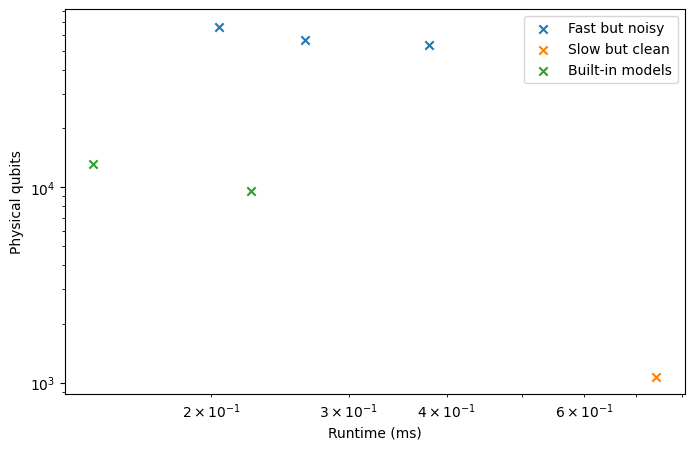

In [6]:
isa_query = SurfaceCode.q() * Litinski19Factory.q()

results = [
    estimate(app, fast_noisy, isa_query, max_error=0.01, name="Fast but noisy"),
    estimate(app, slow_clean, isa_query, max_error=0.01, name="Slow but clean"),
    baseline,
]

plot_estimates(results, figsize=(8, 5), runtime_unit="ms")

## Building a custom QEC ISA transform

An `ISATransform` maps one instruction set to another.  A QEC transform
consumes physical instructions and produces logical instructions by encoding
qubits in an error-correcting code.

The key relationships in any QEC code are:

- **Space**: How many physical qubits per logical qubit?  (Depends on code
  distance.)
- **Time**: How long does one logical operation take?  (Depends on syndrome
  extraction cycles.)
- **Error**: What is the logical error rate?  (Depends on physical error rate,
  code distance, and the code's threshold.)

To implement a QEC transform, subclass `ISATransform` and implement two
methods:

1. `required_isa`: a **static method** that declares what physical
   instructions the transform needs.  Because it is static, it cannot reference
   instance fields (such as the error-correction threshold); instead, you
   specify fixed bounds using `ConstraintBound`.  `ConstraintBound` supports
   comparisons like `.lt(value)` (less than), `.le(value)`, `.eq(value)`,
   `.gt(value)`, and `.ge(value)`.
2. `provided_isa`: computes the logical instruction properties from the
   physical ones and yields one or more ISAs.

The `distance` field uses `metadata={"domain": range(3, 22, 2)}` to tell the
estimator to automatically search over odd distances from 3 to 21.  The
estimator evaluates all distances and keeps only the Pareto-optimal ones.

In [7]:
@dataclass
class GenericQEC(ISATransform):
    """
    A configurable QEC code model with tunable threshold, overhead,
    and error suppression.

    This transform consumes physical H, CNOT, and MEAS_Z instructions and
    produces a logical LATTICE_SURGERY instruction.  The resource formulas
    are parameterized so you can model different QEC code families.

    The logical error rate follows:

        error = crossing_prefactor × (p_physical / threshold) ^ ⌊(d+1)/2⌋

    Space per data qubit is:

        qubits_per_data_qubit × d²
    """

    crossing_prefactor: float = 0.03
    error_correction_threshold: float = 0.01
    qubits_per_data_qubit: int = 2
    syndrome_extraction_depth: int = 4
    _: KW_ONLY
    distance: int = field(default=3, metadata={"domain": range(3, 22, 2)})

    @staticmethod
    def required_isa() -> ISARequirements:
        # required_isa is static, so we cannot reference instance fields here.
        # Instead, we use ConstraintBound to express fixed constraints on the
        # implementation ISA.  ConstraintBound supports .lt(), .le(), .eq(),
        # .gt(), and .ge() comparisons.
        return ISARequirements(
            constraint(H, error_rate=ConstraintBound.lt(0.01)),
            constraint(CNOT, arity=2, error_rate=ConstraintBound.lt(0.01)),
            constraint(MEAS_Z, error_rate=ConstraintBound.lt(0.01)),
        )

    def provided_isa(
        self, impl_isa: ISA, ctx: ISAContext
    ) -> Generator[ISA, None, None]:
        cnot = impl_isa[CNOT]
        h = impl_isa[H]
        meas_z = impl_isa[MEAS_Z]

        # Physical error rate is the worst case across all required gates
        physical_error_rate = max(
            cnot.expect_error_rate(),
            h.expect_error_rate(),
            meas_z.expect_error_rate(),
        )

        d = self.distance

        # Space: physical qubits per data qubit, scaled by distance².
        #
        # Because LATTICE_SURGERY has variable arity (it can operate on any
        # number of logical qubits), space and error_rate must be provided as
        # functions of arity rather than as fixed numbers.  The estimator
        # provides several helpers for this:
        #
        #   linear_function(slope)          → f(n) = slope × n
        #   constant_function(value)        → f(n) = value
        #   block_linear_function(k, s, o)  → f(n) = s × ⌈n/k⌉ + o
        #   generic_function(callable)      → f(n) = callable(n)
        #
        # For QEC codes, resources scale linearly with the number of logical
        # qubits, so linear_function is the natural choice.
        space = linear_function(self.qubits_per_data_qubit * d**2)

        # Time: syndrome extraction cycle × code distance
        code_cycle_time = (
            h.expect_time()
            + self.syndrome_extraction_depth * cnot.expect_time()
            + meas_z.expect_time()
        )
        time = code_cycle_time * d

        # Error: exponential suppression below threshold
        logical_error = self.crossing_prefactor * (
            (physical_error_rate / self.error_correction_threshold)
            ** ((d + 1) // 2)
        )
        error = linear_function(logical_error)

        yield ctx.make_isa(
            ctx.add_instruction(
                LATTICE_SURGERY,
                encoding=LOGICAL,
                arity=None,
                space=space,
                time=time,
                error_rate=error,
                # transform=self records that this instruction was produced by
                # this QEC transform instance, and source=[...] records which
                # physical instructions it was derived from.  Together, they
                # form the provenance chain that you can inspect in the
                # estimation results (see notebook 2).
                transform=self,
                source=[cnot, h, meas_z],
                # Extra keyword arguments (like distance) are stored as
                # properties on the instruction.  This lets you retrieve the
                # code distance used for each Pareto-optimal result when
                # analysing the estimation output.  Further, the property can be
                # required and read by a parent ISATransform to create new
                # logical instructions based on this one.
                distance=d,
            ),
        )

### What if we had a better QEC code?

Let's compare two configurations:

- **Surface-code-like:** threshold 1%, prefactor 0.03, ~2d² physical qubits
  per logical qubit (the `GenericQEC` defaults).
- **Optimistic code:** threshold 3%, prefactor 0.01, ~d² qubits
  per logical qubit (a hypothetical code with better parameters).

We use the built-in `GateBased` architecture and `Litinski19Factory` to isolate
the effect of the QEC code.  Because `GenericQEC` is a dataclass, we can pass
the non-default parameters directly to `.q()`. The estimator fixes those values
while still searching over the `distance` hyperparameter.

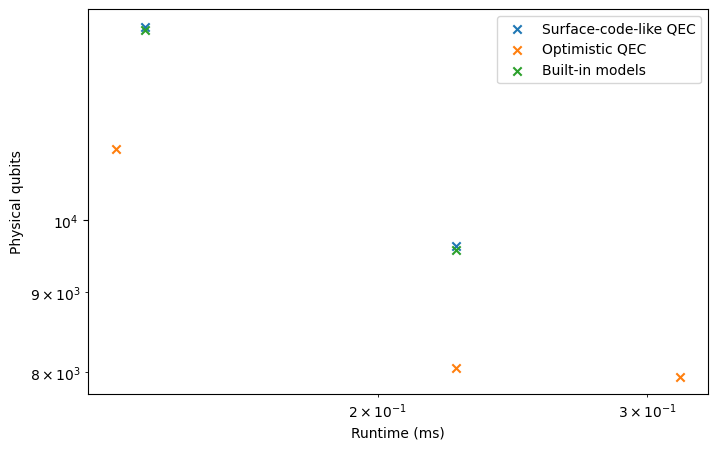

In [8]:
arch = GateBased(error_rate=1e-4, gate_time=100, measurement_time=500)

# Surface-code-like parameters (the defaults)
surface_like = GenericQEC.q() * Litinski19Factory.q()

# Optimistic hypothetical code: higher threshold, lower overhead
optimistic = GenericQEC.q(
    crossing_prefactor=0.01,
    error_correction_threshold=0.03,
    qubits_per_data_qubit=1,
) * Litinski19Factory.q()

results = [
    estimate(app, arch, surface_like, max_error=0.01, name="Surface-code-like QEC"),
    estimate(app, arch, optimistic, max_error=0.01, name="Optimistic QEC"),
    baseline,
]

plot_estimates(results, figsize=(8, 5), runtime_unit="ms")

## Building a custom factory transform

A factory transform produces high-fidelity magic states (typically T states) by
consuming lower-level instructions.  It models the distillation process: take
many noisy copies of a state, run a distillation protocol, and output fewer
copies with lower error.

The built-in `Litinski19Factory` uses pre-computed protocol data from
[arXiv:1905.06903](https://arxiv.org/abs/1905.06903).  Each entry in the table
specifies an output error rate, a space cost in physical qubits (which already
accounts for the QEC overhead inside the factory), and a time cost in syndrome
extraction cycles.

We can build a custom factory that starts from this data and explores "what if"
scenarios by scaling the space and cycle costs:

- `space_factor < 1`: What if the factory were more compact?
- `cycle_factor < 1`: What if distillation were faster?

This lets you study how improvements in factory design propagate through the
full resource estimate, without having to derive the protocols from scratch.

In [9]:
# Reference data from Litinski (arXiv:1905.06903), Table 1.
# Assumes Clifford and T error rates at most 1e-4.
# Each tuple: (output_error_rate, space_in_physical_qubits, cycles)
_LITINSKI_TABLE = [
    (4.4e-8,    810, 18.1),
    (1.5e-9,    762, 36.2),
    (9.3e-10,  1150, 18.1),
    (1.9e-11,  2070, 30.0),
    (2.4e-15, 16400, 90.3),
    (6.3e-25, 18600, 67.8),
]


@dataclass
class ScaledLitinskiFactory(ISATransform):
    """
    A factory transform based on the Litinski (2019) distillation protocols,
    with configurable scaling factors for space and cycle costs.

    The base data is taken directly from Table 1 in arXiv:1905.06903.
    Each entry specifies a distillation protocol's output error rate, space
    footprint (in physical qubits), and time (in syndrome extraction cycles).
    The space already includes the QEC overhead within the factory itself.

    Scaling factors let you explore hypothetical improvements:

    - ``space_factor=0.5`` models a factory that uses half the qubits.
    - ``cycle_factor=0.5`` models a factory that runs twice as fast.

    Note:
        The error rates are kept fixed when scaling.  In practice, changing
        space or cycles would affect error rates too, but modelling that
        relationship requires protocol-specific analysis.
    """

    space_factor: float = 1.0
    cycle_factor: float = 1.0

    @staticmethod
    def required_isa() -> ISARequirements:
        return ISARequirements(
            constraint(T, error_rate=ConstraintBound.le(1e-4)),
            constraint(H, error_rate=ConstraintBound.le(1e-4)),
            constraint(CNOT, arity=2, error_rate=ConstraintBound.le(1e-4)),
            constraint(MEAS_Z, error_rate=ConstraintBound.le(1e-4)),
        )

    def provided_isa(
        self, impl_isa: ISA, ctx: ISAContext
    ) -> Generator[ISA, None, None]:
        cnot = impl_isa[CNOT]
        h = impl_isa[H]
        meas_z = impl_isa[MEAS_Z]
        t = impl_isa[T]

        # Syndrome extraction time from the physical ISA
        syndrome_extraction_time = (
            4 * cnot.expect_time() + h.expect_time() + meas_z.expect_time()
        )

        for error_rate, base_space, base_cycles in _LITINSKI_TABLE:
            # Apply scaling factors to space and time
            space = ceil(base_space * self.space_factor)
            time = ceil(syndrome_extraction_time * base_cycles * self.cycle_factor)

            yield ctx.make_isa(
                ctx.add_instruction(
                    T,
                    encoding=LOGICAL,
                    arity=1,
                    space=space,
                    time=time,
                    error_rate=error_rate,
                    transform=self,
                    source=[cnot, h, meas_z, t],
                ),
            )

### What if the factory were more compact or faster?

Let's compare three scenarios, all using the built-in `SurfaceCode` for QEC:

- **Litinski baseline:** the built-in `Litinski19Factory` (our reference).
- **Compact factory:** `space_factor=0.5`: the factory uses half the physical
  qubits (perhaps due to better routing or a denser layout).
- **Fast factory:** `cycle_factor=0.5`: the factory completes in half the
  cycles (perhaps due to a faster syndrome extraction scheme).

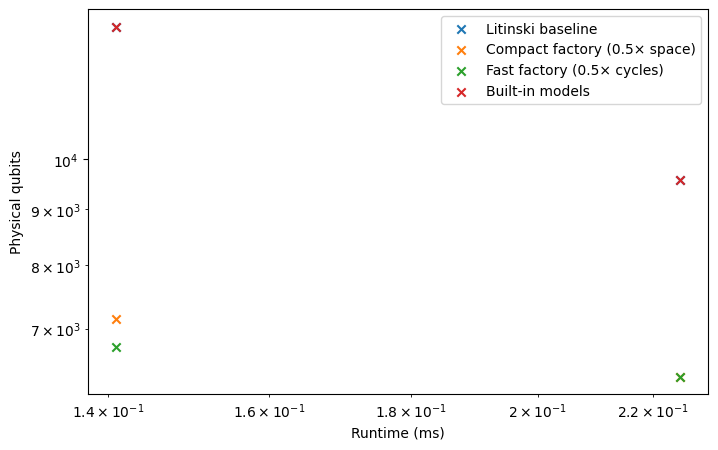

In [10]:
arch = GateBased(error_rate=1e-4, gate_time=100, measurement_time=500)

# Litinski baseline (unscaled, should closely match built-in Litinski19Factory)
litinski_baseline = SurfaceCode.q() * ScaledLitinskiFactory.q()

# Compact factory: half the physical qubits
compact = SurfaceCode.q() * ScaledLitinskiFactory.q(space_factor=0.5)

# Fast factory: half the cycles
fast = SurfaceCode.q() * ScaledLitinskiFactory.q(cycle_factor=0.5)

results = [
    estimate(app, arch, litinski_baseline, max_error=0.01, name="Litinski baseline"),
    estimate(app, arch, compact, max_error=0.01, name="Compact factory (0.5× space)"),
    estimate(app, arch, fast, max_error=0.01, name="Fast factory (0.5× cycles)"),
    baseline,
]

plot_estimates(results, figsize=(8, 5), runtime_unit="ms")

## Composing a full custom stack

Now that we have all three custom layers, let's compose them into a complete
estimation stack.  The `*` operator creates a Cartesian product over all
hyperparameter configurations:

- `GenericQEC` searches over code distances 3–21
- `ScaledLitinskiFactory` produces multiple factory configurations from
  the Litinski protocol table

The estimator evaluates all combinations and returns only the Pareto-optimal
results.

In [11]:
# Full custom stack: custom architecture + custom QEC + custom factory
custom_arch = ParameterizedArchitecture(
    single_qubit_gate_time=100,
    two_qubit_gate_time=200,
    measurement_time=400,
    single_qubit_error_rate=5e-5,
    two_qubit_error_rate=1e-4,
    measurement_error_rate=1e-4,
)

custom_results = estimate(
    app, custom_arch,
    isa_query=GenericQEC.q() * ScaledLitinskiFactory.q(),
    max_error=0.01,
    name="Full custom stack",
)

custom_results.add_qubit_partition_column()
custom_results.add_factory_summary_column()
custom_results.as_frame()

,name,qubits,runtime,error,physical_compute_qubits,physical_factory_qubits,physical_memory_qubits,factories
0,Full custom stack,3151,0 days 00:00:00.000299,0.006790,3150,1,0,1×T
1,Full custom stack,9630,0 days 00:00:00.000292500,0.007312,3150,6480,0,8×T
2,Full custom stack,13284,0 days 00:00:00.000183300,0.009416,1134,12150,0,15×T


> **Why does the first result show only 1 factory qubit?**
>
> When the physical T-gate error rate is low enough, the estimator may find that
> it can meet the overall error budget *without* distillation, using the raw
> physical T gate directly.  In that case the "factory" is just a single physical
> qubit producing T states one at a time, which is why the qubit count is so
> small.  The trade-off is a much longer runtime (thousands of serial T-gate
> executions instead of a few batched factory runs).  Subsequent rows in the
> table use the `ScaledLitinskiFactory` and show the more typical pattern of
> dedicating thousands of physical qubits to a distillation factory in exchange
> for faster execution.

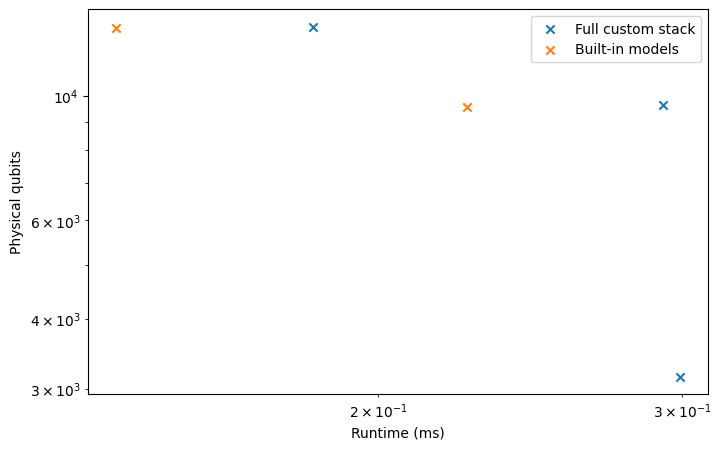

In [12]:
plot_estimates([custom_results, baseline], figsize=(8, 5), runtime_unit="ms")

## Key takeaways

1. **Three extension points.** The estimator's model stack has three layers:
   `Architecture`, QEC `ISATransform`, and factory `ISATransform`, each of
   which can be replaced independently.

2. **Implement two methods.** Every custom QEC or factory model is a dataclass
   that implements `required_isa` (what physical instructions it needs) and
   `provided_isa` (what logical instructions it provides, with resource
   formulas).  A custom architecture implements only `provided_isa`.

3. **Automatic search.** Mark hyperparameters as `KW_ONLY` fields with a
   `metadata={"domain": ...}` and the estimator searches over them
   automatically, keeping only the Pareto-optimal configurations.

4. **Mix and match.** Custom models compose freely with built-in ones using the
   `*` operator.  You can replace one layer while keeping the others at their
   defaults, which is useful for isolating the effect of a single modeling choice.

5. **Provenance tracking.** Pass `transform=self` and `source=[...]` when
   adding instructions to preserve the link between physical and logical
   instructions.  This lets you inspect the full derivation chain in the
   results (see [Analysing Results](2_analysing_results.ipynb)).